# project_21_serine_hydrolase — all notebooks (00→05) in one

This is a **convenience copy** that concatenates the six standalone notebooks in order so you can run the whole project top-to-bottom in a single Colab session. The individual notebooks (`00_setup.ipynb` … `05_validation_plan.ipynb`) remain in this folder and are the canonical deliverables. Sections are separated by dividers; each section keeps its own setup/`import` cells (re-running them is harmless). All synthetic numbers are still labeled `EXAMPLE_DATA`.

---

## ▶︎ Section 1 / 6 — `00_setup.ipynb`

---

# 00 · Environment Setup — De Novo Protein Design Capstone

This is the **shared setup notebook** every project starts from. Run it top to bottom
*once per Colab session*. It:

1. detects your GPU and warns if you're on a weak/absent one,
2. installs a light, pinned core toolset (Biopython, py3Dmol, foldseek-less utilities),
3. optionally installs heavier tools (ColabFold, ESMFold) on demand,
4. prints exact versions for your `LOG.md` (reproducibility is graded).

> **Compute reality.** A free Colab **T4** runs ColabFold, ESMFold, ProteinMPNN, and small
> RFdiffusion jobs. **BindCraft / RFantibody / large RFdiffusion** want an **A100** (Colab Pro+
> or a cluster). Each project's `MANUAL.md` states its tier. Don't fight a T4 to do an A100 job —
> plan your batch sizes around it.

## 1 · GPU & environment check

In [1]:
import subprocess, sys, platform, textwrap

def sh(cmd):
    return subprocess.run(cmd, shell=True, capture_output=True, text=True).stdout.strip()

print("Python :", sys.version.split()[0])
print("Platform:", platform.platform())

gpu = sh("nvidia-smi --query-gpu=name,memory.total --format=csv,noheader 2>/dev/null")
if gpu:
    print("GPU    :", gpu)
    name = gpu.lower()
    if "t4" in name:
        print(textwrap.fill(
            "NOTE: T4 detected. Good for ColabFold/ESMFold/ProteinMPNN/small RFdiffusion. "
            "For BindCraft/RFantibody/large diffusion, switch to A100 (Colab Pro+) or a cluster.", 88))
    elif any(x in name for x in ("a100", "l4", "v100")):
        print("NOTE: capable GPU — heavier tools (BindCraft/RFantibody) are feasible.")
else:
    print("GPU    : NONE FOUND")
    print(textwrap.fill(
        "WARNING: No GPU. Go to Runtime → Change runtime type → Hardware accelerator → GPU. "
        "Structure prediction on CPU is impractically slow.", 88))

Python : 3.11.15
Platform: Linux-6.18.5-x86_64-with-glibc2.39
GPU    : NONE FOUND
Structure prediction on CPU is impractically slow.


## 2 · Pinned core install (fast, T4-friendly)

These are light and used across every project. Pins are conservative; bump them in your repo if needed and **log it**.

In [2]:
# Core utilities used in every project. Quiet + pinned.
%pip -q install biopython==1.84 py3Dmol==2.4.0 numpy pandas matplotlib seaborn tqdm requests 2>/dev/null
print("Core install done.")

Note: you may need to restart the kernel to use updated packages.
Core install done.


In [3]:
# Version stamp — copy this block's output into your LOG.md for reproducibility.
import importlib, datetime
mods = ["Bio", "py3Dmol", "numpy", "pandas", "matplotlib", "seaborn", "tqdm", "requests"]
print("# Environment stamp", datetime.datetime.utcnow().isoformat(timespec="seconds"), "UTC")
for m in mods:
    try:
        v = importlib.import_module(m).__version__
    except Exception:
        v = "n/a"
    print(f"{m:14s} {v}")

# Environment stamp 2026-06-24T03:17:26 UTC
Bio            1.84
py3Dmol        2.4.0


numpy          2.4.6

pandas         3.0.3
matplotlib     3.11.0


seaborn        0.13.2
tqdm           4.68.3
requests       2.33.1


## 3 · Heavy tools — install *on demand*

Don't install these unless your project needs them this session (they're slow to set up).
Each is wrapped in a function so you only pay the cost when you call it.

In [4]:
def install_colabfold():
    """ColabFold (AF2). ~3–5 min on first install. T4 OK."""
    import subprocess
    subprocess.run("pip -q install 'colabfold[alphafold-minus-jax]'", shell=True)
    # On Colab, the standard route is the localcolabfold installer or the ColabFold notebook;
    # here we expose the pip route. If it fails, fall back to the official ColabFold notebook
    # and import your sequences. Log whichever path you used.
    print("ColabFold install attempted. Verify with: from colabfold.batch import run")

def install_esmfold():
    """ESMFold via HuggingFace transformers. T4 OK for <~400 aa."""
    import subprocess
    subprocess.run("pip -q install 'transformers>=4.40' accelerate", shell=True)
    print("ESMFold deps installed. Load with transformers EsmForProteinFolding.")

print("Helpers ready: install_colabfold(), install_esmfold().")

Helpers ready: install_colabfold(), install_esmfold().


## 4 · Reproducibility helpers

Call `set_seeds()` at the top of every run, and use `log()` to append to your `LOG.md`.

In [5]:
import os, random
import numpy as np

def set_seeds(seed: int = 0):
    random.seed(seed); np.random.seed(seed); os.environ["PYTHONHASHSEED"] = str(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass
    print(f"seeds set to {seed}")

def log(msg: str, path: str = "LOG.md"):
    import datetime
    stamp = datetime.datetime.utcnow().isoformat(timespec="seconds")
    with open(path, "a") as fh:
        fh.write(f"- {stamp}Z · {msg}\n")
    print("logged:", msg)

set_seeds(0)
log("Ran 00_setup; environment stamped.")

seeds set to 0
logged: Ran 00_setup; environment stamped.


## 5 · (Optional) Mount Google Drive for persistence

Colab sessions are ephemeral. Mount Drive to keep your `results/` and design pools between sessions.

In [6]:
# from google.colab import drive
# drive.mount("/content/drive")
# WORKDIR = "/content/drive/MyDrive/denovo_capstone/project_XX"
# import os; os.makedirs(WORKDIR, exist_ok=True); os.chdir(WORKDIR)
print("Uncomment to mount Drive and set your working directory.")

Uncomment to mount Drive and set your working directory.


---
**Next:** open `01_define_and_explore.ipynb`. Keep this session alive — re-running `00_setup`
each new session is normal. Record every version and seed in `LOG.md`.

---

## ▶︎ Section 2 / 6 — `01_define_and_explore.ipynb`

---

# 01 · Define & Explore — enzyme design, ester hydrolysis, and the triad theozyme

**Standard slot:** *define & explore.* **For Project 21 this means:** understand de novo enzyme
design and the **serine-hydrolase mechanism**, then **construct the theozyme** (the Ser-His-Asp
triad + the oxyanion hole around the ester tetrahedral intermediate) and run a mock
theozyme→scaffold hello-world, including the catalytic-Ser→Ala dead-mutant control (D0).

Run `00_setup.ipynb` first in this session.

## Why serine hydrolases are a great de novo enzyme target
Serine hydrolases — esterases, lipases, proteases — are the **industrial workhorses** of
biocatalysis (ester synthesis, kinetic resolution of chiral building blocks, detergents). They
all run on the **Ser-His-Asp triad + oxyanion hole**:
- the catalytic **His** (oriented by **Asp/Glu**) deprotonates the **Ser** hydroxyl;
- **Ser-OG attacks the ester carbonyl C**, forming a **tetrahedral intermediate** whose oxyanion
  is stabilised by the **oxyanion hole** (two backbone-amide NHs);
- the intermediate collapses to an acyl-enzyme, which a His-activated water hydrolyses.

The honest history: for decades you could only *borrow and tweak* a natural hydrolase. The **2025
Science work (Lauko et al.)** *designed efficient hydrolases from scratch* — the tractable,
validated frontier result this project reproduces on a general esterase.

## The theozyme — the catalytic motif you must build
A **theozyme** ("theoretical enzyme") is the minimal set of catalytic functional groups placed
around the **tetrahedral intermediate**. For ester hydrolysis the canonical motif is:

| Role | Residue(s) | Job in the TS |
|------|-----------|----------------|
| catalytic Ser | Ser | Ser-OG attacks the ester carbonyl C (the nucleophile) |
| catalytic His | His | deprotonates Ser-OH (general base) |
| catalytic Asp | Asp / Glu | orients & protonates His (charge-relay) |
| oxyanion hole | 2 × backbone-NH (or Ser-OG) | stabilise the developing oxyanion |

You **construct** this from the literature and/or a QM tetrahedral-intermediate model — it is a
teaching template (`data/inputs/theozyme_def.txt`), **not** fabricated experimental data. *Do not
forget the oxyanion hole* — it is easy to omit and decisive for catalysis.

## Setup paths

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_21_serine_hydrolase/notebooks


## Build the theozyme (mock hello-world)
`scripts/enzyme_tools.py` exposes `build_theozyme(reaction)` → a functional-group geometry spec.
The distances/angles it ships are **PLACEHOLDERS** — replace them in `data/inputs/theozyme_def.txt`
(and in `build_theozyme`) with real, cited values during P1. This is the **enzyme-family template**
(Project 18 Kemp): here we override the motif with the Ser-His-Asp triad + oxyanion hole.

In [8]:
from enzyme_tools import build_theozyme

theo = build_theozyme("ester_hydrolysis")
print("Reaction :", theo.reaction)
print("Substrate:", theo.substrate)
print("Provenance:", theo.provenance)
print("\nCatalytic functional groups (PLACEHOLDER geometry — fill from literature/QM):")
for fg in theo.functional_groups:
    ang = f"{fg.target_angle}deg" if fg.target_angle is not None else "n/a"
    print(f"  {fg.role:16s} {fg.residue}/{fg.atom:4s}  d={fg.target_distance}A  angle={ang}")
print("\nCatalytic residues to FIX during sequence design:", theo.catalytic_residue_ids())

Reaction : Ester hydrolysis (serine-hydrolase Ser-His-Asp triad + oxyanion hole; general esterase)
Substrate: chromogenic ester (fast screen: p-nitrophenyl acetate/butyrate, product pNP-olate ~405 nm; acyl-chain scan probes substrate scope)
Provenance: TEMPLATE — student fills geometry from literature/QM (see data/inputs/theozyme_def.txt)

Catalytic functional groups (PLACEHOLDER geometry — fill from literature/QM):
  catalytic_ser    SER/OG    d=2.9A  angle=105.0deg
  catalytic_his    HIS/NE2   d=3.0A  angle=120.0deg
  catalytic_asp    ASP/OD2   d=2.8A  angle=120.0deg
  oxyanion_donor_1 backbone-NH/N     d=3.0A  angle=150.0deg
  oxyanion_donor_2 backbone-NH/N     d=3.0A  angle=150.0deg

Catalytic residues to FIX during sequence design: ['catalytic_ser', 'catalytic_his', 'catalytic_asp', 'oxyanion_donor_1', 'oxyanion_donor_2']


## A first mock scaffold + sequence + the dead-mutant control (no GPU)
`scaffold_motif(...)` (mock) returns placeholder backbones presenting the motif;
`ligandmpnn_fix_catalytic(...)` (mock) designs sequences with the triad fixed; `make_dead_mutant(...)`
builds the **catalytic-Ser→Ala negative control** (same fold, no nucleophile — the perfect negative).
**Every number here is SYNTHETIC** — this only proves the plumbing runs anywhere. Switch to the real
backends (RFdiffusion2/Riff-Diff on an A100; LigandMPNN CPU-fast) in `02_generate.ipynb`.

In [9]:
from enzyme_tools import (scaffold_motif, ligandmpnn_fix_catalytic,
                          catalytic_geometry_rmsd, make_dead_mutant)

scaffolds = scaffold_motif(theo, n=5, method="mock")
print(f"{len(scaffolds)} mock scaffolds; example:")
print(" ", scaffolds[0])

seqs = ligandmpnn_fix_catalytic(scaffolds[0], theo.catalytic_residue_ids(), n=3, tool="mock")
print(f"\n{len(seqs)} mock sequences for {scaffolds[0]['design_id']} "
      f"(fixed roles: {seqs[0]['fixed_catalytic_roles']})")

# Catalytic-Ser->Ala dead mutant (the perfect negative control): pick a Ser in the
# (synthetic) sequence; in a real design this index is the DESIGNED catalytic serine.
seq0 = seqs[0]["sequence"]
ser_idx = seq0.find("S")
dead = make_dead_mutant(seq0, ser_idx)
n_diff = sum(a != b for a, b in zip(seq0, dead))
print(f"\ndead mutant: pos {ser_idx} S->A; differs at exactly {n_diff} position "
      f"(perfect negative control)")

cg = catalytic_geometry_rmsd(None, theo)   # mock, SYNTHETIC
print(f"\ncatalytic_geometry_rmsd (mock, SYNTHETIC) = {cg} A  -> pass if < 0.5 A")
print("NOTE: these are placeholder numbers. The real campaign is in notebook 02.")

5 mock scaffolds; example:
  {'design_id': 'EXAMPLE_DATA_scaffold_000', 'method': 'mock', 'backbone_pdb': None, 'length': 248, 'motif_rmsd': 1.134, 'catalytic_residues': ['catalytic_ser', 'catalytic_his', 'catalytic_asp', 'oxyanion_donor_1', 'oxyanion_donor_2'], 'synthetic': True}

3 mock sequences for EXAMPLE_DATA_scaffold_000 (fixed roles: ['catalytic_ser', 'catalytic_his', 'catalytic_asp', 'oxyanion_donor_1', 'oxyanion_donor_2'])

dead mutant: pos 14 S->A; differs at exactly 1 position (perfect negative control)

catalytic_geometry_rmsd (mock, SYNTHETIC) = 0.614 A  -> pass if < 0.5 A
NOTE: these are placeholder numbers. The real campaign is in notebook 02.


## The metrics that decide an enzyme design
| Metric | Cutoff (`enzyme`) | Means | Does **not** mean |
|--------|-------------------|-------|-------------------|
| scRMSD | ≤ 2.0 Å | designed-vs-predicted backbone self-consistency | activity |
| pLDDT (global) | ≥ 85 | local fold confidence | thermostability / catalysis |
| pLDDT (catalytic) | ≥ 90 | confidence *at the active site* | the geometry is correct |
| **catalytic_geom_rmsd** | **< 0.5 Å** | predicted triad + oxyanion-hole atoms vs the theozyme | **activity** (can still be dead) |

Project-specific orthogonal checks (notebook 04): **pocket accessibility** (the ester docks
oriented toward Ser-OG) and **substrate scope** (which acyl chains fit). The fourth row is the
point of the whole project — and the last column is the message to never forget: **in-silico
catalytic geometry does not guarantee a working enzyme.** Only a kinetic assay does (notebook 05).

## D0 checklist
- [ ] Half-page on de novo enzyme design + the honest serine-hydrolase hit-rate reality.
- [ ] 1-page problem statement with **measurable** success criteria + the controls you'll need.
- [ ] Theozyme spec started in `data/inputs/theozyme_def.txt` (triad + **oxyanion hole**; cite sources).
- [ ] Reproduced mock hello-world (triad + oxyanion-hole spec + a mock scaffold + the dead-mutant control).
- [ ] `LOG.md` entry (tool versions, GPU, seed).

**Next:** `02_generate.ipynb` — scaffold the motif and run LigandMPNN with the catalytic triad fixed.

---

## ▶︎ Section 3 / 6 — `02_generate.ipynb`

---

# 02 · Campaign — theozyme → scaffold → LigandMPNN (catalytic triad fixed)

**Standard slot:** *design campaign.* **For Project 21 this means:** take the triad + oxyanion-hole
theozyme, scaffold it into many backbones (RFdiffusion2 / Riff-Diff — the **A100** step), then
**LigandMPNN sequence design fixing the catalytic triad + oxyanion-hole donors**, and write a
results CSV (D2).

Runs end-to-end on the **mock** backend with no GPU; switch to the real backends on Colab/HPC.

## Setup paths

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_21_serine_hydrolase/notebooks


## Version-verify the pinned upstreams
Tools change. Before a campaign, HTTP-check that the pinned upstream repos still exist, and pin the
commit/tag you actually use. **RFdiffusion2 and Riff-Diff are new and move fast — VERIFY the current
public release/repo at generation time** (do not assert a repo you are unsure of); the others below
are stable enough to head-check.

In [11]:
import requests

# Pinned upstreams (pin the COMMIT/TAG you use in env/requirements.txt + LOG.md):
STABLE_UPSTREAMS = {
    "RFdiffusion (classic motif scaffolding)": "https://github.com/RosettaCommons/RFdiffusion",
    "LigandMPNN (catalytic-residue-fixed seq design)": "https://github.com/dauparas/LigandMPNN",
    "AutoDock Vina (pocket accessibility + substrate scope)": "https://github.com/ccsb-scripps/AutoDock-Vina",
    "OpenMM (active-site MD)": "https://github.com/openmm/openmm",
}
# VERIFY-ONLY (new/fast-moving; confirm the current release before relying on a URL):
VERIFY_UPSTREAMS = [
    "RFdiffusion2 (Dauparas 2025) — VERIFY current public release/repo at generation time",
    "Riff-Diff (Schnettler 2025, Nature) — VERIFY current public release/repo at generation time",
    "Lauko 2025 (Science) de novo serine hydrolases — VERIFY any released designs/coordinates",
]

for name, url in STABLE_UPSTREAMS.items():
    try:
        r = requests.head(url, allow_redirects=True, timeout=15)
        print(f"[{r.status_code}] {name}\n      {url}")
    except Exception as e:
        print(f"[ERR] {name}: {e!r}\n      {url}")
print("\nVERIFY MANUALLY (do not assert a repo URL you are unsure of):")
for v in VERIFY_UPSTREAMS:
    print("  -", v)

[200] RFdiffusion (classic motif scaffolding)
      https://github.com/RosettaCommons/RFdiffusion


[200] LigandMPNN (catalytic-residue-fixed seq design)
      https://github.com/dauparas/LigandMPNN


[200] AutoDock Vina (pocket accessibility + substrate scope)
      https://github.com/ccsb-scripps/AutoDock-Vina


[200] OpenMM (active-site MD)
      https://github.com/openmm/openmm

VERIFY MANUALLY (do not assert a repo URL you are unsure of):
  - RFdiffusion2 (Dauparas 2025) — VERIFY current public release/repo at generation time
  - Riff-Diff (Schnettler 2025, Nature) — VERIFY current public release/repo at generation time
  - Lauko 2025 (Science) de novo serine hydrolases — VERIFY any released designs/coordinates


## 1 · Build the theozyme and scaffold it
The mock path returns placeholder backbones so the loop runs anywhere. On an A100, switch `METHOD`
to `"rfdiffusion2"` or `"riffdiff"` (verify the release) and `N_SCAFFOLDS` to 1000s, biasing toward
compact alpha/beta-hydrolase-like folds with an **open, accessible pocket**.

> **A100 NOTE:** scaffolding 1000s of backbones is the compute bottleneck. Free Colab T4 can do a
> small **RFdiffusion** (classic) motif-scaffolding demo (tens of backbones); the real campaign wants
> an A100 (Colab Pro+) or HPC. The mock backend below needs no GPU at all.

In [12]:
from enzyme_tools import build_theozyme, scaffold_motif

theo = build_theozyme("ester_hydrolysis")

METHOD = "mock"        # -> "rfdiffusion2" | "riffdiff" | "rfdiffusion" on Colab/HPC (verify release)
N_SCAFFOLDS = 12       # -> 1000s for the real campaign

scaffolds = scaffold_motif(theo, n=N_SCAFFOLDS, method=METHOD)
print(f"{len(scaffolds)} scaffolds via method={METHOD!r} (mock numbers are SYNTHETIC)")
print("example:", scaffolds[0])

12 scaffolds via method='mock' (mock numbers are SYNTHETIC)
example: {'design_id': 'EXAMPLE_DATA_scaffold_000', 'method': 'mock', 'backbone_pdb': None, 'length': 223, 'motif_rmsd': 0.874, 'catalytic_residues': ['catalytic_ser', 'catalytic_his', 'catalytic_asp', 'oxyanion_donor_1', 'oxyanion_donor_2'], 'synthetic': True}


## 2 · LigandMPNN sequence design — FIXING the catalytic triad + oxyanion hole
This is the core of enzyme sequence design: redesign the protein but **keep the catalytic triad AND
the oxyanion-hole donors fixed** (and use the ligand/ester-TS context). That is why LigandMPNN, not
vanilla ProteinMPNN, is used. On Colab set `TOOL="ligandmpnn"` (CPU-fast) and pass the fixed-positions
list + ligand/TS context. You may line the (non-catalytic) acyl pocket for a target chain length —
never touch the triad.

In [13]:
from enzyme_tools import ligandmpnn_fix_catalytic

TOOL = "mock"          # -> "ligandmpnn" on Colab (CPU-fast)
SEQS_PER_BACKBONE = 4

catalytic = theo.catalytic_residue_ids()
all_designs = []
for bb in scaffolds:
    seqs = ligandmpnn_fix_catalytic(bb, catalytic, n=SEQS_PER_BACKBONE, tool=TOOL)
    for s in seqs:
        s["scaffold_id"] = bb["design_id"]
        s["scaffold_method"] = bb["method"]
        s["motif_rmsd"] = bb["motif_rmsd"]
        all_designs.append(s)
print(f"{len(all_designs)} sequences total "
      f"({len(scaffolds)} backbones x {SEQS_PER_BACKBONE}); catalytic roles fixed: {catalytic}")

48 sequences total (12 backbones x 4); catalytic roles fixed: ['catalytic_ser', 'catalytic_his', 'catalytic_asp', 'oxyanion_donor_1', 'oxyanion_donor_2']


## 3 · Predict + score (mock geometry, pocket, scope), write the results CSV
On Colab, predict each sequence with AF2/ESMFold, read the **active-site pLDDT**, compute the real
`catalytic_geometry_rmsd` from the predicted PDB, dock the pNP-ester for **pocket accessibility**, and
scan the **acyl-chain series** for substrate scope. Here the mock backend fills SYNTHETIC values so the
CSV — the input to notebook 03 — is produced anywhere.

In [14]:
import pandas as pd
from enzyme_tools import (catalytic_geometry_rmsd, dock_substrate,
                          substrate_scope_scan, active_site_md)

rows = []
for d in all_designs:
    # On Colab, `pred_pdb` is the AF2-predicted PDB path for this design; the mock backend keys off
    # the (non-existent) per-design path string so each design gets DISTINCT SYNTHETIC values.
    pred_pdb = f"results/pred/{d['design_id']}.pdb"
    cg = catalytic_geometry_rmsd(pred_pdb, theo)        # mock -> SYNTHETIC (varies per design)
    dock = dock_substrate(pred_pdb, "p-nitrophenyl acetate")  # mock -> SYNTHETIC (pocket accessibility)
    scope = substrate_scope_scan(pred_pdb, acyl_lengths=(2, 4, 6, 8))  # mock -> SYNTHETIC
    accepted = [r["acyl_length"] for r in scope if r["fits_and_oriented"]]
    md_res = active_site_md(pred_pdb, ns=10.0)          # mock -> SYNTHETIC
    # SYNTHETIC stand-ins for AF2 confidence so the plumbing runs (replace with real predictions):
    import hashlib
    h = int(hashlib.sha256(d["design_id"].encode()).hexdigest(), 16)
    plddt = 78 + (h % 20)            # 78-97, SYNTHETIC
    plddt_cat = 80 + ((h >> 7) % 18) # 80-97, SYNTHETIC
    scrmsd = round(0.8 + ((h >> 11) % 200) / 100.0, 2)  # 0.8-2.8, SYNTHETIC
    rows.append(dict(
        design_id=d["design_id"], scaffold_id=d["scaffold_id"],
        scaffold_method=d["scaffold_method"], sequence=d["sequence"],
        plddt=plddt, plddt_catalytic=plddt_cat, scrmsd=scrmsd,
        catalytic_geom_rmsd=cg, vina_score=dock["vina_score"],
        pose_in_pocket=dock["pose_in_pocket"], oriented_to_ser=dock["oriented_to_ser"],
        accepted_acyl=str(accepted), md_rmsd=md_res["md_rmsd"], synthetic=True))

camp = pd.DataFrame(rows)
camp.to_csv("results/campaign.csv", index=False)
print("wrote results/campaign.csv", camp.shape, "(ALL NUMBERS SYNTHETIC — mock backend)")
print(f"catalytic_geom_rmsd range: {camp['catalytic_geom_rmsd'].min()}-{camp['catalytic_geom_rmsd'].max()} A")
camp.head()

wrote results/campaign.csv (48, 14) (ALL NUMBERS SYNTHETIC — mock backend)
catalytic_geom_rmsd range: 0.162-1.044 A


,design_id,scaffold_id,scaffold_method,sequence,plddt,plddt_catalytic,scrmsd,catalytic_geom_rmsd,vina_score,pose_in_pocket,oriented_to_ser,accepted_acyl,md_rmsd,synthetic
0,EXAMPLE_DATA_scaffold_000_seq00,EXAMPLE_DATA_scaffold_000,mock,RAMTLWVDHMGLPTSSFHNDPWKACEQCHQKDCLAMAICDIRADCI...,97,83,0.97,0.162,-6.25,True,False,[4],3.149,True
1,EXAMPLE_DATA_scaffold_000_seq01,EXAMPLE_DATA_scaffold_000,mock,VNIMVNDSDGFYDRIRMAVYYPFWALNGLHDNFEGWIHMMWINQRY...,95,82,2.10,0.171,-7.32,True,True,[6],3.139,True
2,EXAMPLE_DATA_scaffold_000_seq02,EXAMPLE_DATA_scaffold_000,mock,MYVWPKHEFYDQGIIEGELWEYGTLFRCRFVLCVGEYRMPSGMYMD...,96,85,1.36,0.331,-4.13,True,True,"[4, 8]",1.913,True
3,EXAMPLE_DATA_scaffold_000_seq03,EXAMPLE_DATA_scaffold_000,mock,QHTCLKIWNYSQNMQPANGEHAFLTNGAQPKIKDQCTYMYPIILEI...,80,95,1.80,0.296,-7.24,True,False,"[2, 4, 8]",2.253,True
4,EXAMPLE_DATA_scaffold_001_seq00,EXAMPLE_DATA_scaffold_001,mock,IGLLRAHQIPCLLDHTYYSMRFIVACHMALNEVWNCIGMHVKPMTT...,82,92,0.86,0.623,-6.77,True,True,"[6, 8]",2.597,True


## D2 checklist
- [ ] Scaffolding run logged (method, release/commit, N backbones, seed) — A100 for the real campaign.
- [ ] LigandMPNN sequences with the **triad + oxyanion-hole donors provably fixed** (fixed-positions list logged).
- [ ] `results/campaign.csv` with one row per design (real metrics on Colab; mock here).
- [ ] Design log (every config + seed + output path) + 3–4 page interim report.

**Next:** `03_filter_and_rank.ipynb` — run the shared enzyme filter on `campaign.csv`.

---

## ▶︎ Section 4 / 6 — `03_filter_and_rank.ipynb`

---

# 03 · Filter & Rank — the shared enzyme filter

**Standard slot:** *filter & rank* via `shared/filtering_pipeline.py` — the same module all 25
projects use. **For Project 21** you filter on the **enzyme** cutoffs, with the catalytic-geometry
RMSD (triad + oxyanion hole) as the decisive metric.

Run `00`–`02` first so `results/campaign.csv` exists.

## Setup paths

In [15]:
import sys, os
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_21_serine_hydrolase/notebooks


## Load the shared filtering pipeline
Improvements here are pull-requested back to `shared/` for the whole cohort — do not silently fork it.

In [16]:
import filtering_pipeline as fp
import pandas as pd

print("enzyme cutoffs:", fp.DEFAULT_CUTOFFS["enzyme"])

enzyme cutoffs: {'scrmsd': 2.0, 'plddt': 85, 'plddt_cat': 90, 'cat_geom': 0.5}


## Build `fp.Design` objects (enzyme) from the campaign
Map each campaign row onto an `fp.Design`, carrying the enzyme-specific fields: `plddt`,
**`plddt_catalytic`**, `scrmsd`, and **`catalytic_geom_rmsd`**. The self-consistency layer
(`self_consistency`) checks all of these against the enzyme cutoffs (scrmsd ≤ 2.0, plddt ≥ 85,
plddt_cat ≥ 90, cat_geom ≤ 0.5).

In [17]:
camp = pd.read_csv("results/campaign.csv")

designs = []
for _, r in camp.iterrows():
    designs.append(fp.Design(
        design_id=str(r["design_id"]),
        sequence=str(r.get("sequence", "")),
        design_type="enzyme",
        plddt=float(r["plddt"]),
        plddt_catalytic=float(r["plddt_catalytic"]),
        scrmsd=float(r["scrmsd"]),
        catalytic_geom_rmsd=float(r["catalytic_geom_rmsd"]),
        md_rmsd=float(r["md_rmsd"]),
        extra={"scaffold_method": r["scaffold_method"],
               "pose_in_pocket": bool(r.get("pose_in_pocket", False)),
               "synthetic": True},
    ))
print(len(designs), "enzyme Design objects built (from SYNTHETIC mock metrics)")

48 enzyme Design objects built (from SYNTHETIC mock metrics)


## Run the pipeline (`design_type="enzyme"`) and report
`run_pipeline` applies the layers in order and returns a ranked DataFrame. We use layers 1+3+4
(self-consistency incl. catalytic geometry, physics, and the short-MD dynamics layer); the orthogonal
layer (L2) needs a second predictor's scRMSD, which you add on Colab.

Total designs: 48
  L1 survivors: 6  (12.5%)
  L3 survivors: 6  (12.5%)
  L4 survivors: 4  (8.3%)


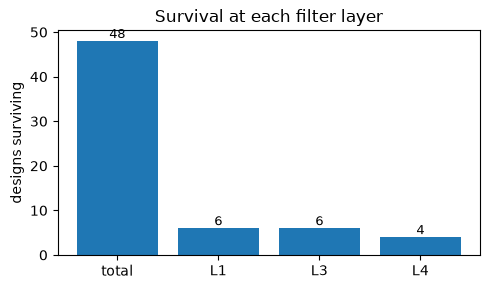

,design_id,design_type,layers_passed,score,scrmsd,plddt,pae_interaction,rosetta_dG,tm_to_pdb
0,EXAMPLE_DATA_scaffold_004_seq01,enzyme,4,3.08,1.38,96.0,None,None,None
1,EXAMPLE_DATA_scaffold_010_seq00,enzyme,4,2.98,1.46,94.0,None,None,None
2,EXAMPLE_DATA_scaffold_010_seq03,enzyme,4,2.77,1.60,87.0,None,None,None
3,EXAMPLE_DATA_scaffold_008_seq01,enzyme,4,2.67,1.80,97.0,None,None,None
4,EXAMPLE_DATA_scaffold_001_seq01,enzyme,3,2.75,1.38,88.0,None,None,None
5,EXAMPLE_DATA_scaffold_011_seq02,enzyme,3,2.49,1.69,93.0,None,None,None
6,EXAMPLE_DATA_scaffold_005_seq00,enzyme,0,2.61,0.82,93.0,None,None,None
7,EXAMPLE_DATA_scaffold_000_seq00,enzyme,0,2.50,0.97,97.0,None,None,None
8,EXAMPLE_DATA_scaffold_007_seq03,enzyme,0,2.47,0.89,86.0,None,None,None
9,EXAMPLE_DATA_scaffold_001_seq00,enzyme,0,2.46,0.86,82.0,None,None,None


In [18]:
df_ranked = fp.run_pipeline(designs, design_type="enzyme", use_layers=(1, 3, 4))
df_ranked.to_csv("results/ranked.csv", index=False)
top = fp.report(df_ranked, top_n=10, save_prefix="results/proj21")
top

## Survival-at-each-layer + catalytic-geometry pass rate (honest accounting)
The **catalytic-geometry layer is where most enzyme designs die** — expect the steepest drop there.
Report the pass rate explicitly; this is the headline benchmark for D3.

In [19]:
import pandas as pd
print("layers_passed distribution:")
print(df_ranked["layers_passed"].value_counts().sort_index())

n = len(df_ranked)
cut = fp.DEFAULT_CUTOFFS["enzyme"]["cat_geom"]
n_geom = int((df_ranked["catalytic_geom_rmsd"] <= cut).sum())
print(f"\ncatalytic-geometry preservation: {n_geom}/{n} "
      f"({100*n_geom/max(n,1):.1f}%) hold the triad < {cut} A  [SYNTHETIC demo numbers]")

layers_passed distribution:
layers_passed
0    42
3     2
4     4
Name: count, dtype: int64

catalytic-geometry preservation: 18/48 (37.5%) hold the triad < 0.5 A  [SYNTHETIC demo numbers]


## D3 (part 1) checklist
- [ ] `results/ranked.csv` produced by the **shared** module with `design_type="enzyme"`.
- [ ] Survival-at-each-layer figure (`results/proj21_survival.png`).
- [ ] Catalytic-geometry preservation rate reported (the headline metric).
- [ ] Mapping assumptions written down (which metrics, which prediction).

**Next:** `04_validate.ipynb` — catalytic-geometry preservation + scaffolding-method comparison + pocket/scope + MD.

---

## ▶︎ Section 5 / 6 — `04_validate.ipynb`

---

# 04 · Validate — geometry preservation, method comparison, pocket & substrate scope

**Standard slot:** *validate (in silico).* **For Project 21 this is the benchmark:** the
**catalytic-geometry preservation rate**, a **scaffolding-method comparison** (RFdiffusion2 vs
Riff-Diff vs motif scaffolding) `[extension]`, and the **pocket-accessibility / substrate-scope** and
active-site-MD figures (D3 pt2).

Needs `results/campaign.csv` (+ `results/ranked.csv` from notebook 03).

## Setup paths

In [20]:
import sys, os
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_21_serine_hydrolase/notebooks


## 1 · Catalytic-geometry preservation — the headline figure
Distribution of catalytic-geometry RMSD vs the 0.5 Å pass bar. The fraction left of the line is the
**preservation rate** — the metric that most distinguishes scaffolding methods. (Numbers here are
SYNTHETIC mock values; on Colab they come from real AF2 predictions.)

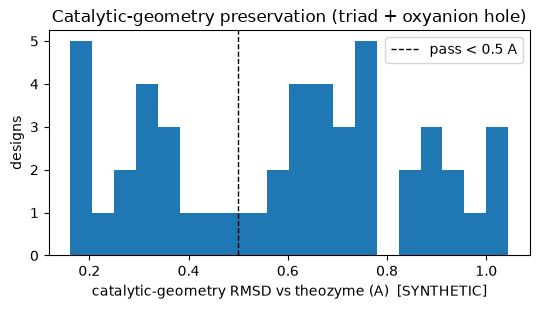

overall catalytic-geometry preservation rate = 37.5%  [SYNTHETIC demo]


In [21]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

camp = pd.read_csv("results/campaign.csv")
cut = 0.5

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.hist(camp["catalytic_geom_rmsd"], bins=20)
ax.axvline(cut, color="k", ls="--", lw=1, label=f"pass < {cut} A")
ax.set_xlabel("catalytic-geometry RMSD vs theozyme (A)  [SYNTHETIC]")
ax.set_ylabel("designs"); ax.set_title("Catalytic-geometry preservation (triad + oxyanion hole)")
ax.legend(); plt.tight_layout()
plt.savefig("results/catalytic_geometry_hist.png", dpi=150); plt.show()

rate = 100 * (camp["catalytic_geom_rmsd"] <= cut).mean()
print(f"overall catalytic-geometry preservation rate = {rate:.1f}%  [SYNTHETIC demo]")

## 2 · Scaffolding-method comparison `[extension]`
Compare the preservation rate (and hit rate) across scaffolding methods. In the real campaign these
are RFdiffusion2 vs Riff-Diff vs classic RFdiffusion motif scaffolding; here a single mock method is
present, so this cell shows the *shape* of the comparison you will populate on Colab.

In [22]:
by_method = (camp.assign(pass_geom=camp["catalytic_geom_rmsd"] <= 0.5)
                 .groupby("scaffold_method")
                 .agg(n=("design_id", "size"),
                      geom_pass_rate=("pass_geom", "mean"),
                      mean_plddt_cat=("plddt_catalytic", "mean"))
                 .reset_index())
by_method["geom_pass_rate"] = (100 * by_method["geom_pass_rate"]).round(1)
print("Scaffolding-method comparison (populate with real methods on Colab):")
print(by_method.to_string(index=False))
print("\n[SYNTHETIC] On Colab: compare rfdiffusion2 vs riffdiff vs rfdiffusion on the SAME theozyme.")

Scaffolding-method comparison (populate with real methods on Colab):
scaffold_method  n  geom_pass_rate  mean_plddt_cat
           mock 48            37.5          88.375

[SYNTHETIC] On Colab: compare rfdiffusion2 vs riffdiff vs rfdiffusion on the SAME theozyme.


## 3 · Pocket accessibility + substrate scope (the project's emphasis)
Geometry is necessary but not sufficient: the ester must physically fit the pocket and orient its
carbonyl toward Ser-OG (docking = **pocket accessibility**), and the **acyl-chain length** the pocket
accepts sets esterase- vs lipase-like **substrate scope**. Here we plot the geometry-passing survivors
by pocket accessibility, and show the acyl-chain scope scan for the best design.

of 18 geometry-passing designs, 12 have an ACCESSIBLE pocket (ester docks in pocket) [SYNTHETIC]


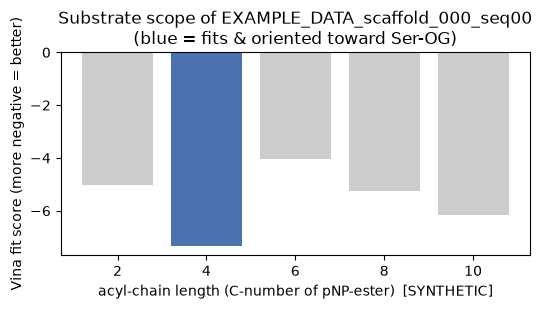

predicted-acceptable acyl chains for EXAMPLE_DATA_scaffold_000_seq00: C[4]  [SYNTHETIC] (short = esterase-like, longer = lipase-like)


In [23]:
import matplotlib.pyplot as plt
from enzyme_tools import substrate_scope_scan

# Pocket accessibility among geometry-passing designs (SYNTHETIC flags from the campaign CSV).
geo = camp[camp["catalytic_geom_rmsd"] <= 0.5].copy()
n_acc = int(geo["pose_in_pocket"].sum()) if "pose_in_pocket" in geo else 0
print(f"of {len(geo)} geometry-passing designs, {n_acc} have an ACCESSIBLE pocket "
      f"(ester docks in pocket) [SYNTHETIC]")

# Acyl-chain substrate-scope scan for the best (lowest catalytic-geom) design [extension].
best_id = camp.sort_values("catalytic_geom_rmsd").iloc[0]["design_id"]
scope = substrate_scope_scan(f"results/pred/{best_id}.pdb", acyl_lengths=(2, 4, 6, 8, 10))
lengths = [r["acyl_length"] for r in scope]
fits = [1 if r["fits_and_oriented"] else 0 for r in scope]
scores = [r["vina_score"] for r in scope]

fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.bar([str(c) for c in lengths], scores, color=["#4c72b0" if f else "#cccccc" for f in fits])
ax.set_xlabel("acyl-chain length (C-number of pNP-ester)  [SYNTHETIC]")
ax.set_ylabel("Vina fit score (more negative = better)")
ax.set_title(f"Substrate scope of {best_id}\n(blue = fits & oriented toward Ser-OG)")
plt.tight_layout(); plt.savefig("results/substrate_scope.png", dpi=150); plt.show()
pref = [c for c, f in zip(lengths, fits) if f]
print(f"predicted-acceptable acyl chains for {best_id}: C{pref}  [SYNTHETIC] "
      "(short = esterase-like, longer = lipase-like)")

## 4 · Active-site MD stability (top candidates)
Short MD (OpenMM) checks the triad + pocket don't drift apart. Plot MD RMSD vs catalytic geometry for
the ranked survivors as orthogonal evidence — a triad that drifts will not catalyse even with perfect
static geometry.

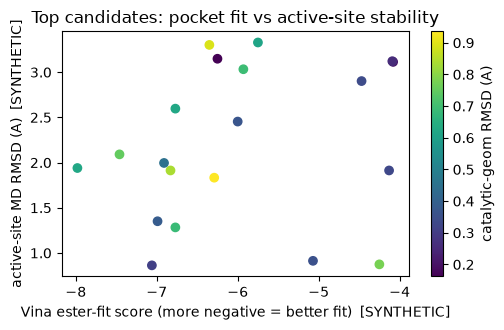

Lower-left + dark points (good fit, stable, good geometry) are the best candidates [SYNTHETIC].


In [24]:
import matplotlib.pyplot as plt
# ranked.csv comes from the shared filter (fp.Design fields); vina_score lives in campaign.csv,
# so merge it back by design_id for the stability view.
try:
    ranked = pd.read_csv("results/ranked.csv")
    ranked = ranked.merge(camp[["design_id", "vina_score"]], on="design_id", how="left")
except FileNotFoundError:
    ranked = camp.copy()

top = ranked.head(min(20, len(ranked)))
fig, ax = plt.subplots(figsize=(5.2, 3.4))
sc = ax.scatter(top["vina_score"], top["md_rmsd"],
                c=top["catalytic_geom_rmsd"], cmap="viridis")
ax.set_xlabel("Vina ester-fit score (more negative = better fit)  [SYNTHETIC]")
ax.set_ylabel("active-site MD RMSD (A)  [SYNTHETIC]")
ax.set_title("Top candidates: pocket fit vs active-site stability")
fig.colorbar(sc, label="catalytic-geom RMSD (A)")
plt.tight_layout(); plt.savefig("results/docking_md.png", dpi=150); plt.show()
print("Lower-left + dark points (good fit, stable, good geometry) are the best candidates [SYNTHETIC].")

## 5 · Honest hit-rate accounting
Report N(pass all layers) / N(generated), and remind the reader of the field reality: even a good
preservation rate is **not** an activity rate. Geometry ≠ catalysis; a pNP-ester kinetic assay (with
the Ser→Ala dead mutant) is required.

In [25]:
n_total = len(camp)
try:
    ranked = pd.read_csv("results/ranked.csv")
    n_hits = int((ranked["layers_passed"] >= 3).sum())
except Exception:
    n_hits = int((camp["catalytic_geom_rmsd"] <= 0.5).sum())
print(f"Hit-rate accounting [SYNTHETIC demo]:")
print(f"  generated            : {n_total}")
print(f"  pass all filter layers: {n_hits}  ({100*n_hits/max(n_total,1):.1f}%)")
print("\nREALITY CHECK: de novo enzyme activity rates are <5% without directed evolution, and")
print("in-silico catalytic geometry does NOT guarantee activity. Only a kinetic assay decides.")

Hit-rate accounting [SYNTHETIC demo]:
  generated            : 48
  pass all filter layers: 6  (12.5%)

REALITY CHECK: de novo enzyme activity rates are <5% without directed evolution, and
in-silico catalytic geometry does NOT guarantee activity. Only a kinetic assay decides.


## D3 (part 2) checklist
- [ ] Catalytic-geometry preservation histogram (`results/catalytic_geometry_hist.png`) + rate.
- [ ] Scaffolding-method comparison table/figure (real methods on Colab) `[extension]`.
- [ ] Pocket-accessibility count + substrate-scope figure (`results/substrate_scope.png`) `[extension]`.
- [ ] Active-site-MD figure on the ranked top set.
- [ ] Honest hit-rate accounting with the "geometry ≠ activity" caveat stated.

**Next:** `05_validation_plan.ipynb` — the pNP-ester kinetic-assay plan + controls + enantioselectivity stretch.

---

## ▶︎ Section 6 / 6 — `05_validation_plan.ipynb`

---

# 05 · Validation plan — pNP-ester kinetics, controls, enantioselectivity

**Standard slot:** *validation plan.* **For Project 21 this means:** turn the catalytic-geometry-
filtered set into a costed **pNP-ester steady-state kinetics + DSF plan** with the right controls
(incl. a **catalytic-Ser→Ala dead mutant**) and an **enantioselectivity / kinetic-resolution** concept
for hits (D4/D5).

This is the deliverable that states, plainly: **in-silico geometry is a hypothesis; the assay tests it.**

## Setup paths

In [26]:
import sys, os
sys.path.insert(0, os.path.abspath("../scripts"))
sys.path.insert(0, os.path.abspath("../../../shared"))
os.makedirs("results", exist_ok=True)
print("paths ready; cwd =", os.getcwd())

paths ready; cwd = /home/user/biofx_python/denovo_protein_design_course/projects/project_21_serine_hydrolase/notebooks


## 1 · Select the synthesis set (< 96 designs)
Pick the top designs from the ranked filter (catalytic geometry first, then an accessible pocket),
capped at **< 96** so they fit a single screening plate with controls. Diversity matters — don't pick
96 near-identical designs; spread across scaffolds and (where relevant) acyl-chain preferences.

In [27]:
import pandas as pd
try:
    ranked = pd.read_csv("results/ranked.csv")
except FileNotFoundError:
    ranked = pd.read_csv("results/campaign.csv")

# Prefer designs passing the catalytic-geometry bar; cap under 96 (leave wells for controls).
ok = ranked[ranked["catalytic_geom_rmsd"] <= 0.5] if "catalytic_geom_rmsd" in ranked else ranked
selected = ok.head(88).copy()
selected.to_csv("results/synthesis_set.csv", index=False)
print(f"selected {len(selected)} designs for synthesis (< 96, leaving wells for controls) [SYNTHETIC ranking]")
print("Diversify across scaffolds + acyl-chain preferences; record why each was chosen in your report.")

selected 18 designs for synthesis (< 96, leaving wells for controls) [SYNTHETIC ranking]
Diversify across scaffolds + acyl-chain preferences; record why each was chosen in your report.


## 2 · The kinetic assay (pNP-ester product readout) + DSF
- **Express + purify:** *E. coli* BL21(DE3), 16–18 °C overnight; His-tag → IMAC → SEC polish.
- **Assay:** follow **p-nitrophenolate** release from p-nitrophenyl acetate (pNPA, C2) or butyrate
  (pNPB, C4) by absorbance at **~405–410 nm** in a plate reader; take initial rates across substrate
  concentrations.
- **Kinetics:** fit **kcat** and **KM** (and kcat/KM) from a Michaelis–Menten / linear-regime fit.
- **DSF:** a thermal-shift (DSF) melt for each construct — confirms the fold and flags unstable designs.
- **Substrate scope:** repeat the assay across the acyl-chain series (C2/C4/C6/C8 pNP-esters) to map
  esterase- vs lipase-like preference.
- **Readout note:** background (non-enzymatic) pNP-ester hydrolysis is non-zero — subtract the
  buffer-only rate, and account for it in every well.

In [28]:
controls = {
    "POSITIVE — natural/reference serine hydrolase": "a verified cutinase/lipase; confirms the assay works",
    "NEGATIVE — catalytic-Ser -> Ala 'dead' mutant": "SAME design, catalytic serine mutated to Ala; the "
        "cleanest negative — loss of activity pins catalysis to that residue (use make_dead_mutant)",
    "NEGATIVE — empty-vector lysate": "no insert; rules out host-background esterase activity",
    "BLANK — buffer + substrate only": "the non-enzymatic background pNP-ester rate to subtract",
}
print("MANDATORY controls (every plate):")
for k, v in controls.items():
    print(f"  - {k}\n      {v}")

# Show the dead-mutant control is a one-residue edit of a selected design (SYNTHETIC sequence).
from enzyme_tools import make_dead_mutant
sel = pd.read_csv("results/synthesis_set.csv")
if "sequence" in sel and len(sel):
    seq = str(sel.iloc[0]["sequence"]); ser_idx = seq.find("S")
    if ser_idx >= 0:
        dead = make_dead_mutant(seq, ser_idx)
        n_diff = sum(a != b for a, b in zip(seq, dead))
        print(f"\ndead-mutant control for {sel.iloc[0]['design_id']}: S{ser_idx}A; differs at "
              f"exactly {n_diff} position (same fold, no nucleophile).")

MANDATORY controls (every plate):
  - POSITIVE — natural/reference serine hydrolase
      a verified cutinase/lipase; confirms the assay works
  - NEGATIVE — catalytic-Ser -> Ala 'dead' mutant
      SAME design, catalytic serine mutated to Ala; the cleanest negative — loss of activity pins catalysis to that residue (use make_dead_mutant)
  - NEGATIVE — empty-vector lysate
      no insert; rules out host-background esterase activity
  - BLANK — buffer + substrate only
      the non-enzymatic background pNP-ester rate to subtract

dead-mutant control for EXAMPLE_DATA_scaffold_004_seq01: S44A; differs at exactly 1 position (same fold, no nucleophile).


## 3 · A costed, plate-based screen (template — fill real prices)
One 96-well plate holds the < 96 designs + the controls above. Cost the gene synthesis, expression,
and assay reagents at your institution's rates; the cell prints a template to fill in your report.

In [29]:
plan = [
    ("Gene synthesis (codon-optimised, screened provider)", "< 96 designs", "fill price/construct"),
    ("Cloning + transformation", "1 plate", "fill"),
    ("Expression + lysis", "1 plate", "fill"),
    ("IMAC purification (plate format)", "1 plate", "fill"),
    ("p-nitrophenyl ester substrates (C2/C4/C6/C8)", "stock", "fill"),
    ("DSF dye + plate-reader time", "per plate", "fill"),
    ("Plate-reader time (kinetics, 405 nm)", "per plate", "fill"),
]
print("Costed reagent/step list (fill institutional prices) [TEMPLATE]:")
for step, scale, cost in plan:
    print(f"  - {step:54s} {scale:14s} {cost}")
print("\nTimeline (typical): synthesis 2-3 wk -> clone/express 1-2 wk -> purify+assay 1-2 wk.")
print("Synthesis MUST go through an IGSC-member, biosecurity-screening provider (low dual-use here, "
      "but it is policy). Wet-lab needs institutional biosafety/ethics sign-off.")

Costed reagent/step list (fill institutional prices) [TEMPLATE]:
  - Gene synthesis (codon-optimised, screened provider)    < 96 designs   fill price/construct
  - Cloning + transformation                               1 plate        fill
  - Expression + lysis                                     1 plate        fill
  - IMAC purification (plate format)                       1 plate        fill
  - p-nitrophenyl ester substrates (C2/C4/C6/C8)           stock          fill
  - DSF dye + plate-reader time                            per plate      fill
  - Plate-reader time (kinetics, 405 nm)                   per plate      fill

Timeline (typical): synthesis 2-3 wk -> clone/express 1-2 wk -> purify+assay 1-2 wk.
Synthesis MUST go through an IGSC-member, biosecurity-screening provider (low dual-use here, but it is policy). Wet-lab needs institutional biosafety/ethics sign-off.


## 4 · Enantioselectivity / kinetic resolution `[stretch]`
The green-chemistry payoff of a designed esterase is often **kinetic resolution** of a racemic ester:
- **Readout:** assay a **chiral pNP-ester** (or follow each enantiomer by chiral HPLC/GC); compute the
  **enantiomeric ratio E** from the relative kcat/KM of the two enantiomers and the ee vs conversion.
- **Design link:** face selectivity is set by the **asymmetric pocket** around the acyl/leaving groups —
  relate measured E to the pocket features your LigandMPNN design installed.
- **Honest framing:** a high E is hard and usually needs iteration; report the E-value trajectory, not
  a single best clone. (Concept only at this stage — no fabricated ee.)

In [30]:
print("Enantioselectivity (stretch): assay a CHIRAL pNP-ester -> initial rates per enantiomer ->")
print("compute the enantiomeric ratio E and ee vs conversion; relate face selectivity to the pocket.")
print("Reminder for the thesis: report the hit rate and the kcat/KM (and E) DISTRIBUTION, not just the")
print("best clone. NO kcat/KM/ee is fabricated here — these come from the wet-lab assay.")

Enantioselectivity (stretch): assay a CHIRAL pNP-ester -> initial rates per enantiomer ->
compute the enantiomeric ratio E and ee vs conversion; relate face selectivity to the pocket.
Reminder for the thesis: report the hit rate and the kcat/KM (and E) DISTRIBUTION, not just the
best clone. NO kcat/KM/ee is fabricated here — these come from the wet-lab assay.


## D4 / D5 checklist
- [ ] `results/synthesis_set.csv`: < 96 diverse, catalytic-geometry-passing, pocket-accessible designs.
- [ ] pNP-ester kinetic-assay + DSF plan: 405 nm product readout, kcat/KM, with **all** controls
      (catalytic-Ser→Ala dead mutant, natural reference, empty vector, blank), costed + timed.
- [ ] Substrate-scope panel (acyl-chain series) in the plan.
- [ ] Enantioselectivity / kinetic-resolution concept `[stretch]`.
- [ ] Thesis chapter + 15-min talk + `v1.0` tagged release; "geometry ≠ activity" stated plainly.

You're done — and this project reuses the Project 18/19 theozyme→scaffold→sequence→geometry template,
swapping in ester hydrolysis (triad + oxyanion hole) and the pocket→scope→kinetics emphasis.